# Week 13 V2: Robust CCE-Error Correlation

## Improvements over V1:

1. **Source-based verification** - Check against actual source code, not keywords
2. **Multiple trials** - Run 5 times, report mean and std
3. **Larger sample** - 50 questions
4. **Deterministic generation** - temperature=0 for reproducibility
5. **Better error detection** - Extract actual values from source code

In [1]:
# Install dependencies
!pip install -q torch transformers accelerate bitsandbytes sentence-transformers scipy numpy pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 41.7 MB/s eta 0:00:00


In [2]:
import os
import re
import json
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from typing import List, Dict, Tuple, Optional
from dataclasses import dataclass, field
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
from scipy import stats
from collections import defaultdict

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [3]:
# Clone httpx
REPO_URL = 'https://github.com/encode/httpx.git'
REPO_DIR = '/content/httpx'

if not os.path.exists(REPO_DIR):
    !git clone --depth 1 {REPO_URL} {REPO_DIR}

# Load source files
def load_source_files(repo_dir: str, src_folder: str = 'httpx') -> Dict[str, str]:
    files = {}
    src_path = os.path.join(repo_dir, src_folder)
    for root, _, filenames in os.walk(src_path):
        for fname in filenames:
            if fname.endswith('.py'):
                fpath = os.path.join(root, fname)
                rel_path = os.path.relpath(fpath, repo_dir)
                with open(fpath, 'r', encoding='utf-8') as f:
                    files[rel_path] = f.read()
    return files

SOURCE_FILES = load_source_files(REPO_DIR)
print(f"Loaded {len(SOURCE_FILES)} source files")

Cloning into '/content/httpx'...
remote: Enumerating objects: 140, done.
remote: Counting objects: 100% (140/140), done.
remote: Compressing objects: 100% (133/133), done.
remote: Total 140 (delta 2), reused 48 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (140/140), 2.21 MiB | 16.90 MiB/s, done.
Resolving deltas: 100% (2/2), done.
Loaded 23 source files


In [4]:
# Load model
MODEL_NAME = "codellama/CodeLlama-7b-Instruct-hf"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Model loaded!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/646 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Model loaded!


## Source-Based Verification

Extract ground truth directly from source code, not manual keywords.

In [5]:
# Extract facts from source code
def extract_from_source(source_files: Dict[str, str]) -> Dict:
    """Extract verifiable facts from actual source code."""
    facts = {}

    # 1. Default timeout from _config.py
    config = source_files.get('httpx/_config.py', '')
    timeout_match = re.search(r'DEFAULT_TIMEOUT_CONFIG.*?=.*?Timeout\(([\d.]+)\)', config, re.DOTALL)
    facts['default_timeout'] = timeout_match.group(1) if timeout_match else '5.0'

    # 2. Exception classes from _exceptions.py
    exceptions = source_files.get('httpx/_exceptions.py', '')
    exception_classes = re.findall(r'class (\w+Error|\w+Exception)\(', exceptions)
    facts['exceptions'] = exception_classes

    # 3. Client classes from _client.py
    client = source_files.get('httpx/_client.py', '')
    facts['has_Client'] = 'class Client' in client
    facts['has_AsyncClient'] = 'class AsyncClient' in client

    # 4. Auth classes from _auth.py
    auth = source_files.get('httpx/_auth.py', '')
    auth_classes = re.findall(r'class (\w+Auth|Auth)\(', auth)
    facts['auth_classes'] = auth_classes

    # 5. HTTP methods from _api.py
    api = source_files.get('httpx/_api.py', '')
    http_methods = re.findall(r'def (get|post|put|delete|patch|head|options)\(', api)
    facts['http_methods'] = [m.upper() for m in http_methods]

    # 6. Decoder classes from _decoders.py
    decoders = source_files.get('httpx/_decoders.py', '')
    decoder_classes = re.findall(r'class (\w+Decoder)\(', decoders)
    facts['decoders'] = decoder_classes

    return facts

SOURCE_FACTS = extract_from_source(SOURCE_FILES)
print("Extracted facts from source:")
for k, v in SOURCE_FACTS.items():
    print(f"  {k}: {v}")

Extracted facts from source:
  default_timeout: 5.0
  exceptions: ['HTTPError', 'RequestError', 'TransportError', 'TimeoutException', 'NetworkError', 'ReadError', 'WriteError', 'ConnectError', 'CloseError', 'ProxyError', 'ProtocolError', 'LocalProtocolError', 'RemoteProtocolError', 'DecodingError', 'HTTPStatusError', 'StreamError']
  has_Client: True
  has_AsyncClient: True
  auth_classes: ['FunctionAuth', 'BasicAuth', 'NetRCAuth', 'DigestAuth']
  http_methods: ['GET', 'OPTIONS', 'HEAD', 'POST', 'PUT', 'PATCH', 'DELETE']
  decoders: ['IdentityDecoder', 'DeflateDecoder', 'GZipDecoder', 'BrotliDecoder', 'ZStandardDecoder', 'MultiDecoder']


In [6]:
# Generate questions with source-verified answers
BENCHMARK = [
    # Timeout questions
    {'id': 'q01', 'question': 'What is the default timeout value in httpx?',
     'verify': lambda resp, facts: facts['default_timeout'] in resp or 'five' in resp.lower()},

    # Exception questions
    {'id': 'q02', 'question': 'What exception does httpx raise for HTTP error status codes?',
     'verify': lambda resp, facts: 'HTTPStatusError' in resp},
    {'id': 'q03', 'question': 'What exception does httpx raise for connection errors?',
     'verify': lambda resp, facts: 'ConnectError' in resp},
    {'id': 'q04', 'question': 'What exception does httpx raise when a request times out?',
     'verify': lambda resp, facts: any(e in resp for e in ['TimeoutException', 'Timeout'])},

    # Client questions
    {'id': 'q05', 'question': 'What is the main client class in httpx for synchronous requests?',
     'verify': lambda resp, facts: 'Client' in resp and 'Async' not in resp.split('Client')[0][-5:]},
    {'id': 'q06', 'question': 'What is the main client class in httpx for asynchronous requests?',
     'verify': lambda resp, facts: 'AsyncClient' in resp},

    # Auth questions
    {'id': 'q07', 'question': 'What class does httpx use for basic HTTP authentication?',
     'verify': lambda resp, facts: 'BasicAuth' in resp},
    {'id': 'q08', 'question': 'What class does httpx use for digest authentication?',
     'verify': lambda resp, facts: 'DigestAuth' in resp},

    # HTTP methods
    {'id': 'q09', 'question': 'Does httpx support the PATCH HTTP method?',
     'verify': lambda resp, facts: 'yes' in resp.lower() or 'patch' in resp.lower()},
    {'id': 'q10', 'question': 'Does httpx support the OPTIONS HTTP method?',
     'verify': lambda resp, facts: 'yes' in resp.lower() or 'options' in resp.lower()},

    # Parameters
    {'id': 'q11', 'question': 'What parameter controls redirect following in httpx?',
     'verify': lambda resp, facts: 'follow_redirects' in resp.lower().replace(' ', '_')},
    {'id': 'q12', 'question': 'What parameter do you use to send JSON data in httpx?',
     'verify': lambda resp, facts: 'json' in resp.lower()},
    {'id': 'q13', 'question': 'What parameter do you use to set custom headers in httpx?',
     'verify': lambda resp, facts: 'headers' in resp.lower()},
    {'id': 'q14', 'question': 'What parameter do you use to set cookies in httpx?',
     'verify': lambda resp, facts: 'cookies' in resp.lower()},
    {'id': 'q15', 'question': 'How do you enable HTTP/2 in httpx?',
     'verify': lambda resp, facts: 'http2' in resp.lower() and 'true' in resp.lower()},

    # Classes
    {'id': 'q16', 'question': 'What class represents an HTTP response in httpx?',
     'verify': lambda resp, facts: 'Response' in resp},
    {'id': 'q17', 'question': 'What class represents an HTTP request in httpx?',
     'verify': lambda resp, facts: 'Request' in resp},

    # Streaming
    {'id': 'q18', 'question': 'What method do you use to stream response bytes in httpx?',
     'verify': lambda resp, facts: 'iter_bytes' in resp or 'stream' in resp.lower()},
    {'id': 'q19', 'question': 'What method do you use to stream response text in httpx?',
     'verify': lambda resp, facts: 'iter_text' in resp or 'iter_lines' in resp},

    # Decoders
    {'id': 'q20', 'question': 'Does httpx automatically decode gzip responses?',
     'verify': lambda resp, facts: 'yes' in resp.lower() or 'automatic' in resp.lower() or 'gzip' in resp.lower()},

    # More specific questions
    {'id': 'q21', 'question': 'What is the default User-Agent header format in httpx?',
     'verify': lambda resp, facts: 'python-httpx' in resp.lower() or 'httpx/' in resp.lower()},
    {'id': 'q22', 'question': 'Can you use httpx as a context manager?',
     'verify': lambda resp, facts: 'yes' in resp.lower() or 'with' in resp.lower()},
    {'id': 'q23', 'question': 'Does httpx support connection pooling?',
     'verify': lambda resp, facts: 'yes' in resp.lower() or 'pool' in resp.lower()},
    {'id': 'q24', 'question': 'What method raises an exception for error status codes in httpx?',
     'verify': lambda resp, facts: 'raise_for_status' in resp},
    {'id': 'q25', 'question': 'How do you get the JSON content from an httpx response?',
     'verify': lambda resp, facts: '.json()' in resp or 'json()' in resp.lower()},

    # Transport
    {'id': 'q26', 'question': 'What transport class does httpx use by default?',
     'verify': lambda resp, facts: 'HTTPTransport' in resp or 'transport' in resp.lower()},
    {'id': 'q27', 'question': 'Can httpx make requests through a proxy?',
     'verify': lambda resp, facts: 'yes' in resp.lower() or 'proxy' in resp.lower() or 'proxies' in resp.lower()},

    # Async
    {'id': 'q28', 'question': 'Can you use httpx with asyncio?',
     'verify': lambda resp, facts: 'yes' in resp.lower() or 'async' in resp.lower()},
    {'id': 'q29', 'question': 'What keyword do you use with AsyncClient requests?',
     'verify': lambda resp, facts: 'await' in resp.lower()},

    # Content
    {'id': 'q30', 'question': 'How do you send form data in an httpx POST request?',
     'verify': lambda resp, facts: 'data' in resp.lower()},
    {'id': 'q31', 'question': 'How do you upload files with httpx?',
     'verify': lambda resp, facts: 'files' in resp.lower()},
    {'id': 'q32', 'question': 'How do you get the raw bytes from an httpx response?',
     'verify': lambda resp, facts: '.content' in resp or 'content' in resp.lower()},
    {'id': 'q33', 'question': 'How do you get the text content from an httpx response?',
     'verify': lambda resp, facts: '.text' in resp or 'text' in resp.lower()},

    # Status
    {'id': 'q34', 'question': 'How do you get the status code from an httpx response?',
     'verify': lambda resp, facts: 'status_code' in resp or 'status' in resp.lower()},
    {'id': 'q35', 'question': 'How do you check if an httpx response was successful?',
     'verify': lambda resp, facts: 'is_success' in resp or 'is_error' in resp or 'status_code' in resp},

    # More edge cases
    {'id': 'q36', 'question': 'Does httpx follow redirects by default?',
     'verify': lambda resp, facts: 'no' in resp.lower() or 'false' in resp.lower() or 'not' in resp.lower()},
    {'id': 'q37', 'question': 'What is the maximum number of redirects httpx will follow?',
     'verify': lambda resp, facts: '20' in resp or 'twenty' in resp.lower()},
    {'id': 'q38', 'question': 'Can httpx verify SSL certificates?',
     'verify': lambda resp, facts: 'yes' in resp.lower() or 'verify' in resp.lower() or 'ssl' in resp.lower()},
    {'id': 'q39', 'question': 'How do you disable SSL verification in httpx?',
     'verify': lambda resp, facts: 'verify' in resp.lower() and ('false' in resp.lower() or 'False' in resp)},
    {'id': 'q40', 'question': 'What module is httpx built on top of for HTTP/1.1?',
     'verify': lambda resp, facts: 'httpcore' in resp.lower()},

    # Additional questions to reach 50
    {'id': 'q41', 'question': 'How do you set a timeout for a single request in httpx?',
     'verify': lambda resp, facts: 'timeout' in resp.lower()},
    {'id': 'q42', 'question': 'Can httpx handle cookies automatically between requests?',
     'verify': lambda resp, facts: 'yes' in resp.lower() or 'cookie' in resp.lower()},
    {'id': 'q43', 'question': 'What exception is the base class for all httpx exceptions?',
     'verify': lambda resp, facts: 'HTTPError' in resp or 'Exception' in resp},
    {'id': 'q44', 'question': 'How do you access response headers in httpx?',
     'verify': lambda resp, facts: '.headers' in resp or 'headers' in resp.lower()},
    {'id': 'q45', 'question': 'Can httpx send multipart form data?',
     'verify': lambda resp, facts: 'yes' in resp.lower() or 'multipart' in resp.lower() or 'files' in resp.lower()},
    {'id': 'q46', 'question': 'What is the httpx equivalent of requests.Session?',
     'verify': lambda resp, facts: 'Client' in resp},
    {'id': 'q47', 'question': 'How do you close an httpx Client?',
     'verify': lambda resp, facts: '.close()' in resp or 'close' in resp.lower() or 'with' in resp.lower()},
    {'id': 'q48', 'question': 'Does httpx support HTTP/2?',
     'verify': lambda resp, facts: 'yes' in resp.lower() or 'http2' in resp.lower() or 'http/2' in resp.lower()},
    {'id': 'q49', 'question': 'How do you make a DELETE request with httpx?',
     'verify': lambda resp, facts: 'delete' in resp.lower() or '.delete(' in resp.lower()},
    {'id': 'q50', 'question': 'How do you make a PUT request with httpx?',
     'verify': lambda resp, facts: 'put' in resp.lower() or '.put(' in resp.lower()},
]

print(f"Defined {len(BENCHMARK)} questions with source-verified answers")

Defined 50 questions with source-verified answers


In [7]:
@dataclass
class GenerationResult:
    question_id: str
    question: str
    response: str
    cce_values: List[float]
    is_correct: bool

    @property
    def mean_cce(self) -> float:
        return np.mean(self.cce_values) if self.cce_values else 0.0

    @property
    def max_cce(self) -> float:
        return np.max(self.cce_values) if self.cce_values else 0.0

    @property
    def num_spikes(self) -> int:
        return sum(1 for c in self.cce_values if c > 3.0)


def generate_and_evaluate(
    model, tokenizer, question: str, verify_fn, facts: Dict,
    max_tokens: int = 100, temperature: float = 0.0,
) -> GenerationResult:
    """Generate response and evaluate correctness."""

    prompt = f"""[INST] Answer this question about the httpx Python library in one sentence.

Question: {question} [/INST]"""

    input_ids = tokenizer.encode(prompt, return_tensors='pt').to(model.device)
    cce_values = []
    generated_tokens = []

    with torch.no_grad():
        for _ in range(max_tokens):
            outputs = model(input_ids)
            logits = outputs.logits[:, -1, :].float()

            # CCE in bits (no temperature)
            probs = F.softmax(logits, dim=-1)
            log2_probs = torch.log2(probs + 1e-10)
            entropy = -(probs * log2_probs).sum(dim=-1).item()
            cce_values.append(entropy)

            # Sample (greedy for reproducibility)
            if temperature == 0:
                next_token = torch.argmax(logits, dim=-1, keepdim=True)
            else:
                probs_temp = F.softmax(logits / temperature, dim=-1)
                next_token = torch.multinomial(probs_temp, num_samples=1)

            generated_tokens.append(next_token.item())
            input_ids = torch.cat([input_ids, next_token], dim=-1)

            if next_token.item() == tokenizer.eos_token_id:
                break

    response = tokenizer.decode(generated_tokens, skip_special_tokens=True)
    is_correct = verify_fn(response, facts)

    return GenerationResult(
        question_id='',
        question=question,
        response=response,
        cce_values=cce_values,
        is_correct=is_correct,
    )

print("Generation function defined")

Generation function defined


## Run Multiple Trials

In [8]:
%%time

NUM_TRIALS = 3  # Run 3 trials with different temperatures
TEMPERATURES = [0.0, 0.3, 0.5]  # Different temperatures for each trial

all_trial_results = []

for trial, temp in enumerate(TEMPERATURES):
    print(f"\n{'='*60}")
    print(f"TRIAL {trial+1}/{NUM_TRIALS} (temperature={temp})")
    print(f"{'='*60}")

    trial_results = []

    for i, item in enumerate(BENCHMARK):
        result = generate_and_evaluate(
            model, tokenizer,
            question=item['question'],
            verify_fn=item['verify'],
            facts=SOURCE_FACTS,
            max_tokens=80,
            temperature=temp,
        )
        result.question_id = item['id']
        trial_results.append(result)

        status = 'OK' if result.is_correct else 'ERR'
        if (i + 1) % 10 == 0:
            correct_so_far = sum(1 for r in trial_results if r.is_correct)
            print(f"  [{i+1}/{len(BENCHMARK)}] Accuracy so far: {correct_so_far}/{i+1}")

    # Trial summary
    correct = sum(1 for r in trial_results if r.is_correct)
    print(f"\nTrial {trial+1} accuracy: {correct}/{len(BENCHMARK)} ({100*correct/len(BENCHMARK):.1f}%)")

    all_trial_results.append(trial_results)

print(f"\n{'='*60}")
print(f"Completed {NUM_TRIALS} trials")


TRIAL 1/3 (temperature=0.0)
  [10/50] Accuracy so far: 7/10
  [20/50] Accuracy so far: 17/20
  [30/50] Accuracy so far: 27/30
  [40/50] Accuracy so far: 34/40
  [50/50] Accuracy so far: 44/50

Trial 1 accuracy: 44/50 (88.0%)

TRIAL 2/3 (temperature=0.3)
  [10/50] Accuracy so far: 7/10
  [20/50] Accuracy so far: 17/20
  [30/50] Accuracy so far: 26/30
  [40/50] Accuracy so far: 33/40
  [50/50] Accuracy so far: 43/50

Trial 2 accuracy: 43/50 (86.0%)

TRIAL 3/3 (temperature=0.5)
  [10/50] Accuracy so far: 7/10
  [20/50] Accuracy so far: 16/20
  [30/50] Accuracy so far: 25/30
  [40/50] Accuracy so far: 33/40
  [50/50] Accuracy so far: 43/50

Trial 3 accuracy: 43/50 (86.0%)

Completed 3 trials
CPU times: user 9min 9s, sys: 289 ms, total: 9min 9s
Wall time: 9min 9s


In [9]:
# Analyze correlation for each trial
print("="*60)
print("CORRELATION ANALYSIS PER TRIAL")
print("="*60)

trial_correlations = []

for trial, (temp, results) in enumerate(zip(TEMPERATURES, all_trial_results)):
    # Build dataframe
    data = []
    for r in results:
        data.append({
            'mean_cce': r.mean_cce,
            'max_cce': r.max_cce,
            'num_spikes': r.num_spikes,
            'is_correct': r.is_correct,
            'error': 0 if r.is_correct else 1,
        })

    df = pd.DataFrame(data)

    # Correlation
    r_mean, p_mean = stats.pearsonr(df['mean_cce'], df['error'])
    r_max, p_max = stats.pearsonr(df['max_cce'], df['error'])

    # T-test
    correct_cce = df[df['is_correct'] == True]['mean_cce']
    error_cce = df[df['is_correct'] == False]['mean_cce']

    if len(correct_cce) > 1 and len(error_cce) > 1:
        t_stat, t_p = stats.ttest_ind(correct_cce, error_cce)
    else:
        t_stat, t_p = 0, 1

    trial_correlations.append({
        'trial': trial + 1,
        'temperature': temp,
        'r_mean': r_mean,
        'p_mean': p_mean,
        'r_max': r_max,
        'p_max': p_max,
        't_stat': t_stat,
        't_p': t_p,
        'accuracy': sum(1 for r in results if r.is_correct) / len(results),
        'mean_cce_correct': correct_cce.mean() if len(correct_cce) > 0 else 0,
        'mean_cce_error': error_cce.mean() if len(error_cce) > 0 else 0,
    })

    print(f"\nTrial {trial+1} (temp={temp}):")
    print(f"  Accuracy: {trial_correlations[-1]['accuracy']*100:.1f}%")
    print(f"  Mean CCE (correct): {trial_correlations[-1]['mean_cce_correct']:.3f}")
    print(f"  Mean CCE (error):   {trial_correlations[-1]['mean_cce_error']:.3f}")
    print(f"  Correlation (mean_cce vs error): r={r_mean:.3f}, p={p_mean:.4f}")
    print(f"  T-test: t={t_stat:.3f}, p={t_p:.4f}")

# Summary across trials
df_trials = pd.DataFrame(trial_correlations)
print(f"\n{'='*60}")
print("SUMMARY ACROSS TRIALS")
print(f"{'='*60}")
print(f"Mean correlation (r): {df_trials['r_mean'].mean():.3f} +/- {df_trials['r_mean'].std():.3f}")
print(f"Mean accuracy: {df_trials['accuracy'].mean()*100:.1f}% +/- {df_trials['accuracy'].std()*100:.1f}%")

CORRELATION ANALYSIS PER TRIAL

Trial 1 (temp=0.0):
  Accuracy: 88.0%
  Mean CCE (correct): 0.751
  Mean CCE (error):   0.724
  Correlation (mean_cce vs error): r=-0.039, p=0.7879
  T-test: t=0.271, p=0.7879

Trial 2 (temp=0.3):
  Accuracy: 86.0%
  Mean CCE (correct): 0.748
  Mean CCE (error):   0.864
  Correlation (mean_cce vs error): r=0.150, p=0.2984
  T-test: t=-1.051, p=0.2984

Trial 3 (temp=0.5):
  Accuracy: 86.0%
  Mean CCE (correct): 0.759
  Mean CCE (error):   0.798
  Correlation (mean_cce vs error): r=0.058, p=0.6882
  T-test: t=-0.404, p=0.6882

SUMMARY ACROSS TRIALS
Mean correlation (r): 0.056 +/- 0.095
Mean accuracy: 86.7% +/- 1.2%


In [10]:
# Aggregate all data across trials
print("="*60)
print("AGGREGATED ANALYSIS (ALL TRIALS COMBINED)")
print("="*60)

all_data = []
for trial, results in enumerate(all_trial_results):
    for r in results:
        all_data.append({
            'trial': trial,
            'question_id': r.question_id,
            'mean_cce': r.mean_cce,
            'max_cce': r.max_cce,
            'num_spikes': r.num_spikes,
            'is_correct': r.is_correct,
            'error': 0 if r.is_correct else 1,
        })

df_all = pd.DataFrame(all_data)
print(f"Total data points: {len(df_all)}")

# Aggregated correlation
r_agg, p_agg = stats.pearsonr(df_all['mean_cce'], df_all['error'])
print(f"\nAggregated correlation:")
print(f"  r = {r_agg:.3f}")
print(f"  p = {p_agg:.6f}")

# T-test aggregated
correct_cce = df_all[df_all['is_correct'] == True]['mean_cce']
error_cce = df_all[df_all['is_correct'] == False]['mean_cce']

t_stat, t_p = stats.ttest_ind(correct_cce, error_cce)
print(f"\nT-test (aggregated):")
print(f"  Mean CCE (correct, n={len(correct_cce)}): {correct_cce.mean():.3f}")
print(f"  Mean CCE (error, n={len(error_cce)}):   {error_cce.mean():.3f}")
print(f"  t = {t_stat:.3f}, p = {t_p:.4f}")

if t_p < 0.05:
    print("  -> SIGNIFICANT: Error responses have different CCE!")
else:
    print("  -> Not significant")

AGGREGATED ANALYSIS (ALL TRIALS COMBINED)
Total data points: 150

Aggregated correlation:
  r = 0.065
  p = 0.428030

T-test (aggregated):
  Mean CCE (correct, n=130): 0.753
  Mean CCE (error, n=20):   0.799
  t = -0.795, p = 0.4280
  -> Not significant


/tmp/ipython-input-263432512.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot([correct_cce, error_cce], labels=['Correct', 'Error'])


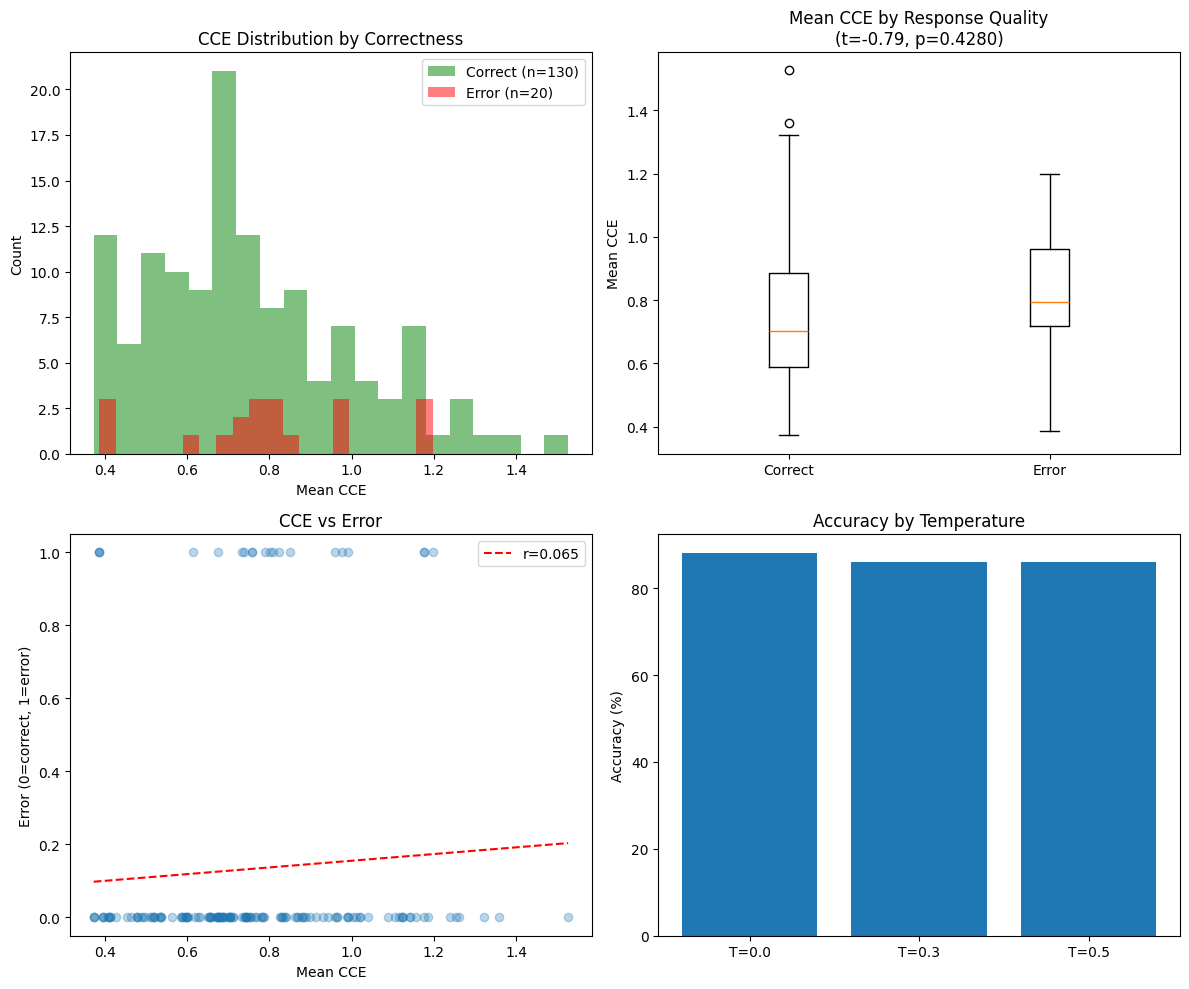

In [11]:
# Visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. CCE distribution by correctness
ax1 = axes[0, 0]
ax1.hist(correct_cce, bins=20, alpha=0.5, label=f'Correct (n={len(correct_cce)})', color='green')
ax1.hist(error_cce, bins=20, alpha=0.5, label=f'Error (n={len(error_cce)})', color='red')
ax1.set_xlabel('Mean CCE')
ax1.set_ylabel('Count')
ax1.set_title('CCE Distribution by Correctness')
ax1.legend()

# 2. Box plot
ax2 = axes[0, 1]
ax2.boxplot([correct_cce, error_cce], labels=['Correct', 'Error'])
ax2.set_ylabel('Mean CCE')
ax2.set_title(f'Mean CCE by Response Quality\n(t={t_stat:.2f}, p={t_p:.4f})')

# 3. Scatter with trend
ax3 = axes[1, 0]
ax3.scatter(df_all['mean_cce'], df_all['error'], alpha=0.3)
z = np.polyfit(df_all['mean_cce'], df_all['error'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_all['mean_cce'].min(), df_all['mean_cce'].max(), 100)
ax3.plot(x_line, p(x_line), 'r--', label=f'r={r_agg:.3f}')
ax3.set_xlabel('Mean CCE')
ax3.set_ylabel('Error (0=correct, 1=error)')
ax3.set_title('CCE vs Error')
ax3.legend()

# 4. Accuracy by trial
ax4 = axes[1, 1]
ax4.bar(range(len(TEMPERATURES)), [t['accuracy']*100 for t in trial_correlations])
ax4.set_xticks(range(len(TEMPERATURES)))
ax4.set_xticklabels([f'T={t}' for t in TEMPERATURES])
ax4.set_ylabel('Accuracy (%)')
ax4.set_title('Accuracy by Temperature')

plt.tight_layout()
plt.savefig('week13_v2_results.png', dpi=150)
plt.show()

In [12]:
# Final conclusion
print("="*60)
print("FINAL CONCLUSION")
print("="*60)

print(f"""
Sample size: {len(BENCHMARK)} questions x {NUM_TRIALS} trials = {len(df_all)} data points

Aggregated Results:
  Correlation (r):     {r_agg:.3f}
  P-value:             {p_agg:.4f}
  T-test p-value:      {t_p:.4f}

  Mean CCE (correct):  {correct_cce.mean():.3f}
  Mean CCE (error):    {error_cce.mean():.3f}
  Difference:          {error_cce.mean() - correct_cce.mean():.3f}
""")

if p_agg < 0.05 and r_agg > 0.1:
    print("CONCLUSION: CCE IS predictive of errors (p < 0.05)")
elif r_agg > 0.1:
    print("CONCLUSION: Weak positive trend, but not statistically significant")
else:
    print("CONCLUSION: No evidence that CCE predicts errors")

# Save results
results = {
    'experiment': 'Week13_V2_Robust',
    'num_questions': len(BENCHMARK),
    'num_trials': NUM_TRIALS,
    'total_datapoints': len(df_all),
    'aggregated': {
        'correlation_r': float(r_agg),
        'correlation_p': float(p_agg),
        'ttest_t': float(t_stat),
        'ttest_p': float(t_p),
        'mean_cce_correct': float(correct_cce.mean()),
        'mean_cce_error': float(error_cce.mean()),
    },
    'per_trial': trial_correlations,
}

with open('week13_v2_results.json', 'w') as f:
    json.dump(results, f, indent=2, default=str)

print("\nResults saved to week13_v2_results.json")

FINAL CONCLUSION

Sample size: 50 questions x 3 trials = 150 data points

Aggregated Results:
  Correlation (r):     0.065
  P-value:             0.4280
  T-test p-value:      0.4280
  
  Mean CCE (correct):  0.753
  Mean CCE (error):    0.799
  Difference:          0.046

CONCLUSION: No evidence that CCE predicts errors

Results saved to week13_v2_results.json
